1. Ingestion & Profiling

#Ingestion: Load the data

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno

df_raw = pd.read_csv('ops_sensor_log_dirty.csv')

#Profiling: Check data health

In [14]:
print("--- INFO ---")
df_raw.info() # Shows column names, non-null counts, and data types

--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5015 entries, 0 to 5014
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   timestamp      5015 non-null   object 
 1   Zone           4984 non-null   object 
 2   Shift          4962 non-null   object 
 3   Pressure_PSI   4975 non-null   float64
 4   Temperature_C  4975 non-null   float64
 5   Flow_Rate_LPM  4966 non-null   float64
dtypes: float64(3), object(3)
memory usage: 235.2+ KB


In [16]:
print("\n--- DESCRIBE ---")
print(df_raw.describe()) # Shows summary statistics (mean, min, max) to spot wild outliers


--- DESCRIBE ---
       Pressure_PSI  Temperature_C  Flow_Rate_LPM
count   4975.000000    4975.000000    4966.000000
mean     255.254281      68.982323     999.275681
std      845.810206      78.829078     231.769525
min      -50.000000    -273.150000     600.007437
25%      160.753008      55.023155     797.417014
50%      200.294439      64.808608     996.286415
75%      240.099173      74.527006    1201.361276
max    15000.000000    1500.000000    1399.755865


#Optional: Visualize missing data

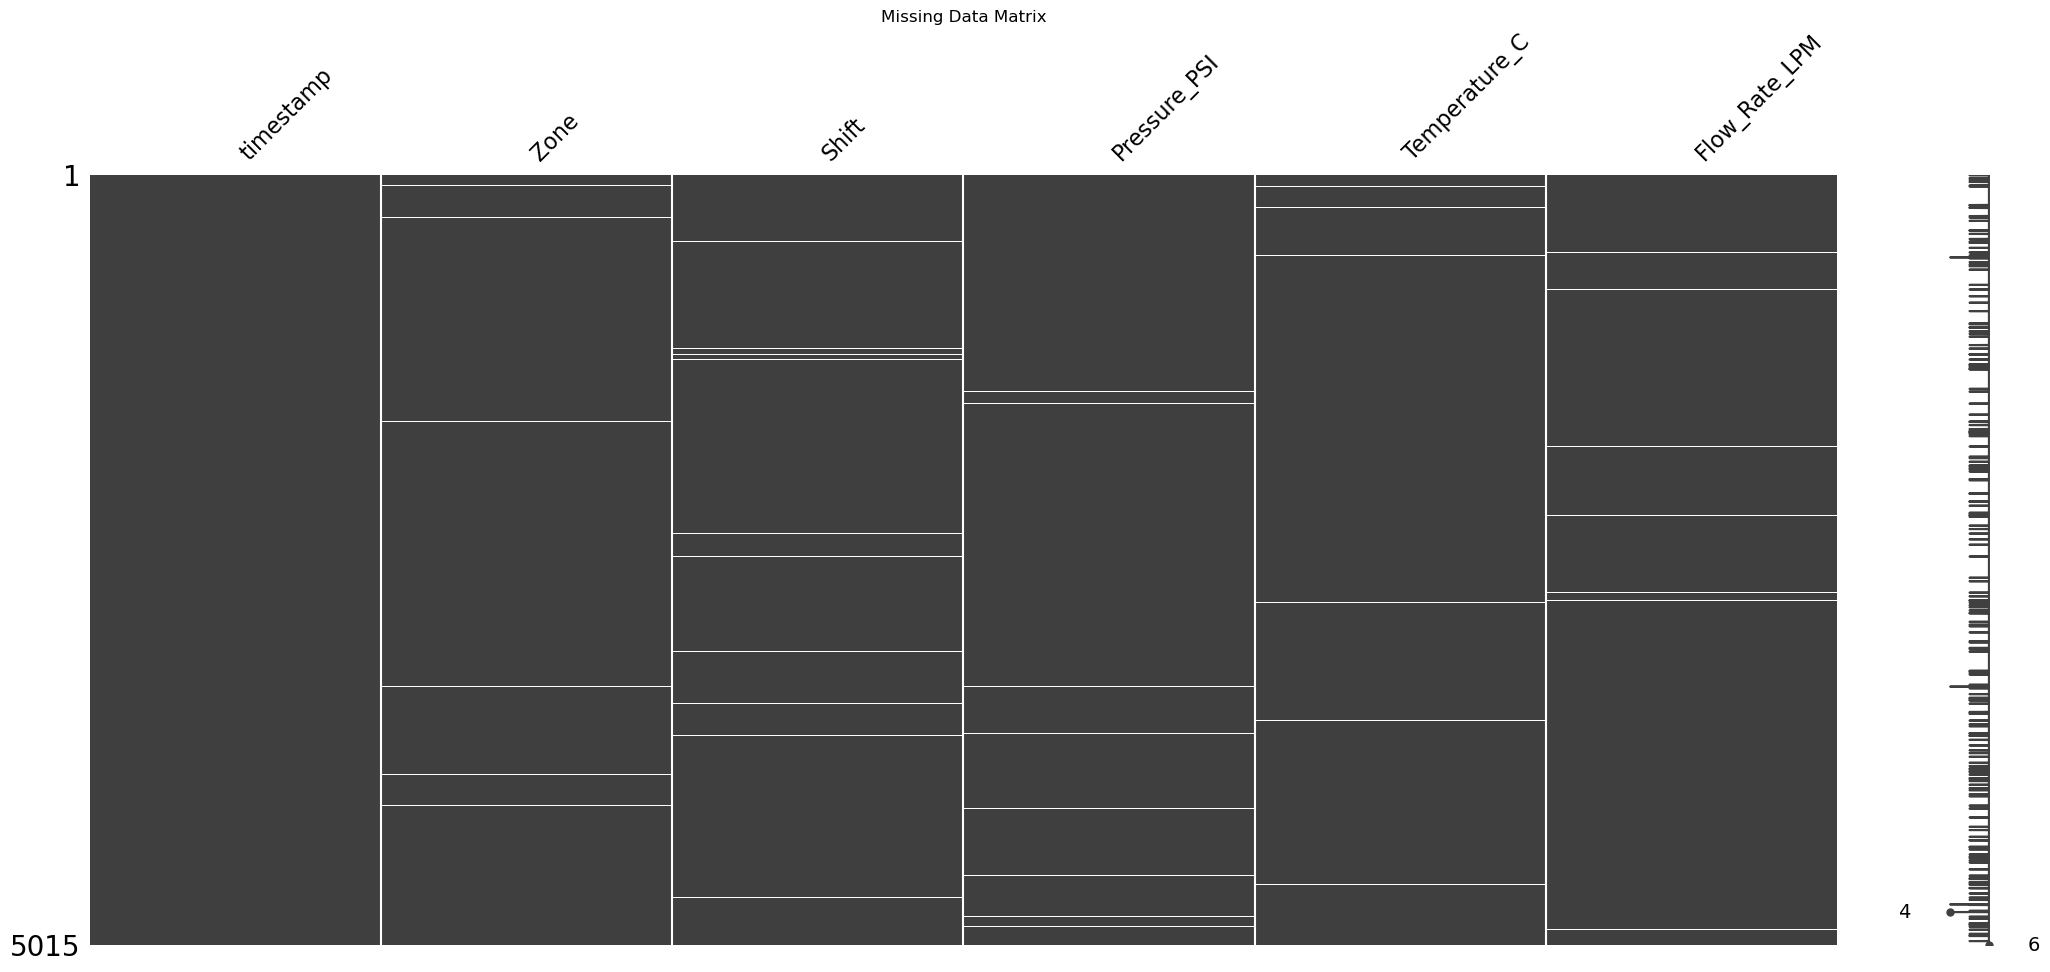

In [17]:
msno.matrix(df_raw)
plt.title("Missing Data Matrix")
plt.show()

## Data Health Report

Based on the initial data profiling using `.info()`, `.describe()`, and `missingno`, several data quality issues were identified that must be addressed in the cleaning pipeline:

*   **Issue 1: Missing Values**
    The dataset contains 5015 total entries, but several columns have missing data. For example, the `Shift` column only has 4962 non-null values (missing 53 entries), and `Pressure_PSI` is missing 40 entries. These gaps will need to be handled to ensure accurate time-series analysis.
*   **Issue 2: Incorrect Data Types** 
    The `timestamp` column is currently loaded as an `object` (string) instead of a proper `datetime` format. This prevents us from doing time-based indexing and resampling.
*   **Issue 3: Extreme Outliers (Sensor Errors)**
    The summary statistics reveal physically impossible sensor readings. The `Pressure_PSI` column has an extreme maximum of 15,000 PSI and an impossible minimum of -50 PSI. Similarly, `Temperature_C` recorded a minimum of -273.15°C (absolute zero). These outliers must be filtered out as they will heavily skew our rolling averages.

2. Cleaning Pipeline

In [19]:
def clean_ops_data(df):
    # Create a copy so we don't alter the original raw dataframe
    clean_df = df.copy()
    
    # 1. Convert timestamps to datetime objects
    # FIX: Changed 'Timestamp' to lowercase 'timestamp'
    clean_df['timestamp'] = pd.to_datetime(clean_df['timestamp'], errors='coerce')
    
    # Drop rows where the timestamp was completely broken
    clean_df = clean_df.dropna(subset=['timestamp'])
    
    # 2. Handle missing values (Justification: Forward fill is best for continuous sensor data)
    # FIX: Changed 'Pressure' to 'Pressure_PSI'
    clean_df['Pressure_PSI'] = clean_df['Pressure_PSI'].ffill()
    
    # 3. Remove exact duplicates
    clean_df = clean_df.drop_duplicates()
    
    # 4. Standardize categorical columns (e.g., stripping spaces, making uppercase)
    if 'Zone' in clean_df.columns:
        clean_df['Zone'] = clean_df['Zone'].astype(str).str.strip().str.upper()
        
    # 5. Filter out physically impossible sensor readings (Outliers)
    # FIX: Changed 'Pressure' to 'Pressure_PSI'
    clean_df = clean_df[(clean_df['Pressure_PSI'] > 0) & (clean_df['Pressure_PSI'] < 1000)]
    
    return clean_df

# Apply the function to your raw data
df_cleaned = clean_ops_data(df_raw)

1. Actual data (first 5 rows):

In [20]:
df_cleaned.head()

,timestamp,Zone,Shift,Pressure_PSI,Temperature_C,Flow_Rate_LPM
0,2026-07-01 18:28:00,ZONE_SOUTH,Night,159.443407,83.599922,693.413088
1,2026-06-26 10:10:00,ZONE_CENTRAL,NaN,271.325543,54.108382,933.590883
2,2026-06-29 22:10:00,ZONE_CENTRAL,Morning,207.832279,72.549214,863.540549
3,2026-06-30 07:22:00,ZONE_EAST,Night,203.110883,73.029484,1189.537650
4,2026-07-01 02:28:00,ZONE_NORTH,Morning,239.773496,73.752762,983.672559


2. Verify the Data Types and Missing Values are fixed:

In [21]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4949 entries, 0 to 5014
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   timestamp      4949 non-null   datetime64[ns]
 1   Zone           4949 non-null   object        
 2   Shift          4898 non-null   object        
 3   Pressure_PSI   4949 non-null   float64       
 4   Temperature_C  4909 non-null   float64       
 5   Flow_Rate_LPM  4901 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(2)
memory usage: 270.6+ KB


3. Verify the Outliers are gone:

In [22]:
df_cleaned.describe()

,timestamp,Pressure_PSI,Temperature_C,Flow_Rate_LPM
count,4949,4949.000000,4909.000000,4901.000000
mean,2026-06-28 10:17:11.432612608,200.134015,69.024945,999.436496
min,2026-01-07 09:10:00,120.029631,-273.150000,600.007437
25%,2026-06-26 17:20:00,161.068895,55.013383,797.193564
50%,2026-06-28 11:02:00,200.368275,64.791074,997.599759
75%,2026-06-30 04:48:00,239.770355,74.526743,1201.237046
max,2026-07-01 22:38:00,279.958604,1500.000000,1399.755865
std,NaN,46.166582,79.346848,231.851755


4. See how many rows you dropped:

In [ ]:
print(f"Original rows: {len(df_raw)}")
print(f"Cleaned rows: {len(df_cleaned)}")
print(f"Rows removed: {len(df_raw) - len(df_cleaned)}")